In [1]:
import itertools
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as smt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from evds import evdsAPI

warnings.filterwarnings("ignore")

In [2]:
def forecast_model_secici(
    df,
    col="Satış Gelirleri_reel",
    exog_df=None,
    exog_cols=None,
    freq="QS-MAR",
    test_size=0.20,
    forecast_steps=4,
    log = False,
    plot=True
):
    warnings.filterwarnings("ignore")

    # -------------------------
    # Veri hazırlığı
    # -------------------------
    data = pd.DataFrame(df[col]).copy()
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()
    data = data.asfreq(freq)

    if log:
        data[f"log_{col}"] = np.log1p(data[col])
        y = data[f"log_{col}"].dropna()
    else:
        y = data[col].dropna()

    split_idx = int(len(y) * (1 - test_size))
    train = y.iloc[:split_idx]
    test = y.iloc[split_idx:]

    results = []
    predictions = {}

    # -------------------------
    # Exog hazırlığı
    # -------------------------
    use_exog = exog_df is not None and exog_cols is not None

    if use_exog:
        exog = exog_df.copy()
        exog.index = pd.to_datetime(exog.index)
        exog = exog.sort_index().asfreq(freq)

        if isinstance(exog_cols, str):
            exog_cols = [exog_cols]

        exog = exog[exog_cols]
        exog = exog.loc[y.index]

        exog_train = exog.loc[train.index]
        exog_test = exog.loc[test.index]
    else:
        exog_train = None
        exog_test = None

    # -------------------------
    # Plot helper
    # -------------------------
    def plot_best_prediction(y_pred, model_name):
        plt.figure(figsize=(14, 6))
        train.plot(label="TRAIN")
        test.plot(label="TEST")
        y_pred.plot(label=f"PREDICTION - {model_name}")
        plt.title(f"En İyi Model: {model_name}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # -------------------------
    # SES
    # -------------------------
    alphas = np.arange(0.01, 1, 0.10)

    best_mae = np.inf
    best_alpha = None
    best_pred = None

    for alpha in alphas:
        try:
            model = SimpleExpSmoothing(train).fit(
                smoothing_level=alpha,
                optimized=False
            )
            y_pred = model.forecast(len(test))
            y_pred = pd.Series(y_pred, index=test.index)
            mae = mean_absolute_error(test, y_pred)

            if mae < best_mae:
                best_mae = mae
                best_alpha = alpha
                best_pred = y_pred
        except:
            pass

    if best_pred is not None:
        results.append({
            "model": "SES",
            "mae": best_mae,
            "params": {"alpha": best_alpha}
        })
        predictions["SES"] = best_pred

    # -------------------------
    # DES
    # -------------------------
    betas = np.arange(0.01, 1, 0.10)

    best_mae = np.inf
    best_params = None
    best_pred = None

    for alpha in alphas:
        for beta in betas:
            try:
                model = ExponentialSmoothing(
                    train,
                    trend="add"
                ).fit(
                    smoothing_level=alpha,
                    smoothing_trend=beta,
                    optimized=False
                )

                y_pred = model.forecast(len(test))
                y_pred = pd.Series(y_pred, index=test.index)
                mae = mean_absolute_error(test, y_pred)

                if mae < best_mae:
                    best_mae = mae
                    best_params = {"alpha": alpha, "beta": beta}
                    best_pred = y_pred
            except:
                pass

    if best_pred is not None:
        results.append({
            "model": "DES",
            "mae": best_mae,
            "params": best_params
        })
        predictions["DES"] = best_pred

    # -------------------------
    # TES / Holt-Winters
    # -------------------------
    alphas_tes = betas_tes = gammas_tes = np.arange(0.10, 1, 0.20)
    abg = list(itertools.product(alphas_tes, betas_tes, gammas_tes))

    best_mae = np.inf
    best_params = None
    best_pred = None

    for alpha, beta, gamma in abg:
        try:
            model = ExponentialSmoothing(
                train,
                trend="add",
                seasonal="add",
                seasonal_periods=4
            ).fit(
                smoothing_level=alpha,
                smoothing_trend=beta,
                smoothing_seasonal=gamma,
                optimized=False
            )

            y_pred = model.forecast(len(test))
            y_pred = pd.Series(y_pred, index=test.index)
            mae = mean_absolute_error(test, y_pred)

            if mae < best_mae:
                best_mae = mae
                best_params = {
                    "alpha": alpha,
                    "beta": beta,
                    "gamma": gamma
                }
                best_pred = y_pred
        except:
            pass

    if best_pred is not None:
        results.append({
            "model": "TES",
            "mae": best_mae,
            "params": best_params
        })
        predictions["TES"] = best_pred

    # -------------------------
    # ARIMA
    # -------------------------
    p = d = q = range(0, 4)
    pdq = list(itertools.product(p, d, q))

    best_mae = np.inf
    best_order = None
    best_pred = None

    for order in pdq:
        try:
            model = sm.tsa.arima.ARIMA(train, order=order).fit()
            y_pred = model.forecast(steps=len(test))
            y_pred = pd.Series(y_pred, index=test.index)
            mae = mean_absolute_error(test, y_pred)

            if mae < best_mae:
                best_mae = mae
                best_order = order
                best_pred = y_pred
        except:
            pass

    if best_pred is not None:
        results.append({
            "model": "ARIMA",
            "mae": best_mae,
            "params": {"order": best_order}
        })
        predictions["ARIMA"] = best_pred

    # -------------------------
    # SARIMA
    # -------------------------
    p = d = q = range(0, 2)
    pdq = list(itertools.product(p, d, q))
    seasonal_pdq = [
        (x[0], x[1], x[2], 4)
        for x in itertools.product(p, d, q)
    ]

    best_mae = np.inf
    best_order = None
    best_seasonal_order = None
    best_pred = None

    for order in pdq:
        for seasonal_order in seasonal_pdq:
            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fitted = model.fit(disp=False)

                y_pred = fitted.get_forecast(
                    steps=len(test)
                ).predicted_mean

                y_pred = pd.Series(y_pred, index=test.index)
                mae = mean_absolute_error(test, y_pred)

                if mae < best_mae:
                    best_mae = mae
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_pred = y_pred
            except:
                pass

    if best_pred is not None:
        results.append({
            "model": "SARIMA",
            "mae": best_mae,
            "params": {
                "order": best_order,
                "seasonal_order": best_seasonal_order
            }
        })
        predictions["SARIMA"] = best_pred

    # -------------------------
    # SARIMAX - Enflasyon Exog
    # -------------------------
    if use_exog:
        best_mae = np.inf
        best_order = None
        best_seasonal_order = None
        best_pred = None

        for order in pdq:
            for seasonal_order in seasonal_pdq:
                try:
                    model = SARIMAX(
                        train,
                        exog=exog_train,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )

                    fitted = model.fit(disp=False)

                    y_pred = fitted.get_forecast(
                        steps=len(test),
                        exog=exog_test
                    ).predicted_mean

                    y_pred = pd.Series(y_pred, index=test.index)
                    mae = mean_absolute_error(test, y_pred)

                    if mae < best_mae:
                        best_mae = mae
                        best_order = order
                        best_seasonal_order = seasonal_order
                        best_pred = y_pred
                except:
                    pass

        if best_pred is not None:
            results.append({
                "model": "SARIMAX_EXOG",
                "mae": best_mae,
                "params": {
                    "order": best_order,
                    "seasonal_order": best_seasonal_order,
                    "exog_cols": exog_cols
                }
            })
            predictions["SARIMAX_EXOG"] = best_pred

    # -------------------------
    # MAE tablosu
    # -------------------------
    mae_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)

    print("\n📊 MODEL MAE SONUÇLARI\n")
    display(mae_df[["model", "mae", "params"]])

    # -------------------------
    # En iyi model
    # -------------------------
    best_model_name = mae_df.loc[0, "model"]
    best_params = mae_df.loc[0, "params"]
    best_test_pred = predictions[best_model_name]

    if plot:
        plot_best_prediction(best_test_pred, best_model_name)

    # -------------------------
    # Final modeli tüm veriyle tekrar fit et
    # -------------------------
    if best_model_name == "SES":
        final_model = SimpleExpSmoothing(y).fit(
            smoothing_level=best_params["alpha"],
            optimized=False
        )
        future_log_pred = final_model.forecast(forecast_steps)

    elif best_model_name == "DES":
        final_model = ExponentialSmoothing(
            y,
            trend="add"
        ).fit(
            smoothing_level=best_params["alpha"],
            smoothing_trend=best_params["beta"],
            optimized=False
        )
        future_log_pred = final_model.forecast(forecast_steps)

    elif best_model_name == "TES":
        final_model = ExponentialSmoothing(
            y,
            trend="add",
            seasonal="add",
            seasonal_periods=4
        ).fit(
            smoothing_level=best_params["alpha"],
            smoothing_trend=best_params["beta"],
            smoothing_seasonal=best_params["gamma"],
            optimized=False
        )
        future_log_pred = final_model.forecast(forecast_steps)

    elif best_model_name == "ARIMA":
        final_model = sm.tsa.arima.ARIMA(
            y,
            order=best_params["order"]
        ).fit()
        future_log_pred = final_model.forecast(steps=forecast_steps)

    elif best_model_name == "SARIMA":
        final_model = SARIMAX(
            y,
            order=best_params["order"],
            seasonal_order=best_params["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        future_log_pred = final_model.get_forecast(
            steps=forecast_steps
        ).predicted_mean

    elif best_model_name == "SARIMAX_EXOG":
        raise ValueError(
            "SARIMAX_EXOG final forecast için future_exog gerekir. "
            "Fonksiyona gelecek dönem enflasyon tahminlerini ayrıca vermelisin."
        )

    if log:
        # log1p ters dönüşüm
        future_forecast = pd.DataFrame({
            f"Log {col} Tahmin": future_log_pred,
            f"{col} Tahmin": np.expm1(future_log_pred)
        })
    else:
        future_forecast = pd.DataFrame({
            f"{col} Tahmin": future_log_pred})

    return {
        "mae_results": mae_df,
        "best_model_name": best_model_name,
        "best_params": best_params,
        "best_test_prediction": best_test_pred,
        "final_model": final_model,
        "future_forecast": future_forecast
    }

In [3]:
with open("C:/Users/okand/OneDrive/Desktop/Works/evds_api.txt") as file:
    api_key = file.read()

In [4]:
evds = evdsAPI(api_key)
makro_data = evds.get_data(['TP.FG.J0','TP.TUFE1YI.T1'],startdate="01-12-2019",enddate="01-12-2025", frequency = 5) 
makro_data

,Tarih,TP_FG_J0,TP_TUFE1YI_T1
0,2019-12,440.50,454.08
1,2020-1,446.45,462.42
2,2020-2,448.02,464.64
3,2020-3,450.58,468.69
4,2020-4,454.43,474.69
...,...,...,...
68,2025-8,3261.72,4518.89
69,2025-9,3367.22,4632.89
70,2025-10,3453.09,4708.20
71,2025-11,3482.96,4747.63


In [5]:
makro_data.columns = ["Tarih", "TUFE", "UFE"]
makro_data["log_TUFE"] = np.log1p(makro_data["TUFE"])
makro_data["log_UFE"] = np.log1p(makro_data["UFE"])
makro_data["tufe_yillik"] = makro_data["TUFE"].pct_change(4)
makro_data["ufe_yillik"] = makro_data["UFE"].pct_change(4)
makro_data["ufe_tufe_spread"] = makro_data["log_UFE"] - makro_data["log_TUFE"]

makro_data.tail(10)

,Tarih,TUFE,UFE,log_TUFE,log_UFE,tufe_yillik,ufe_yillik,ufe_tufe_spread
63,2025-3,2954.69,4017.30,7.991487,8.298614,0.111944,0.076611,0.307127
64,2025-4,3043.23,4128.19,8.021003,8.325837,0.133609,0.101873,0.304833
65,2025-5,3089.74,4230.69,8.036166,8.350357,0.095788,0.095656,0.314191
66,2025-6,3132.17,4334.94,8.049801,8.374694,0.086145,0.099399,0.324893
67,2025-7,3196.66,4409.73,8.070175,8.391795,0.081894,0.097685,0.321621
68,2025-8,3261.72,4518.89,8.090316,8.416243,0.071795,0.094642,0.325926
69,2025-9,3367.22,4632.89,8.122140,8.441152,0.089807,0.095067,0.319012
70,2025-10,3453.09,4708.20,8.147314,8.457273,0.102459,0.086105,0.309959
71,2025-11,3482.96,4747.63,8.155925,8.465611,0.089562,0.076626,0.309687
72,2025-12,3513.87,4783.04,8.164758,8.473041,0.077306,0.058455,0.308283


In [6]:
makro_data.set_index("Tarih", inplace=True)
makro_data.index = pd.to_datetime(makro_data.index, format="%Y-%m")


📊 MODEL MAE SONUÇLARI



,model,mae,params
0,SARIMA,0.011227,"{'order': (1, 1, 0), 'seasonal_order': (0, 1, ..."
1,DES,0.013099,"{'alpha': 0.91, 'beta': 0.01}"
2,TES,0.022380,"{'alpha': 0.5000000000000001, 'beta': 0.900000..."
3,ARIMA,0.022696,"{'order': (0, 3, 3)}"
4,SES,0.218363,{'alpha': 0.91}


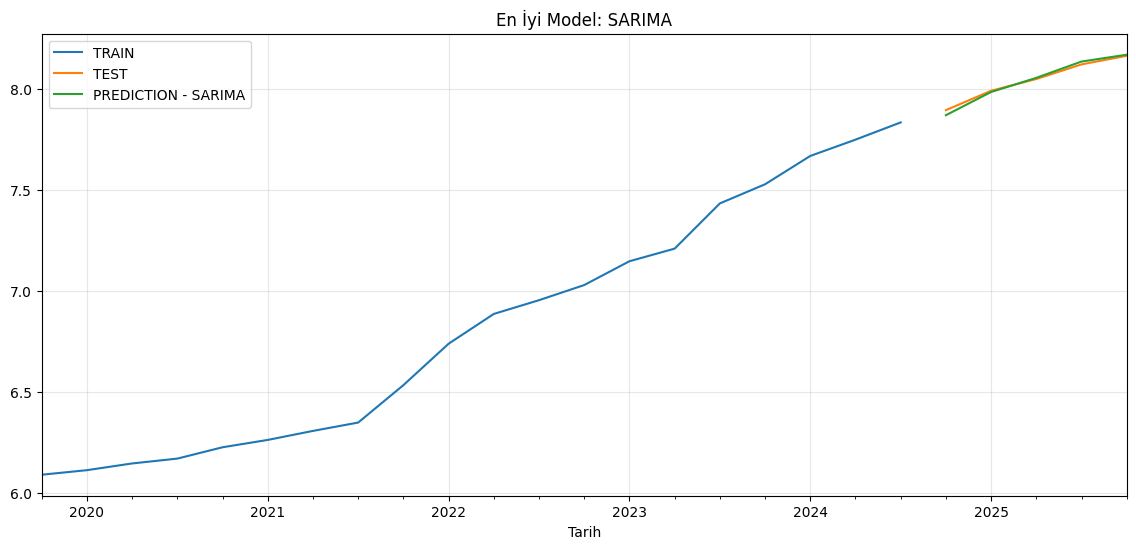

In [7]:
sonuc = forecast_model_secici(
    df=makro_data,
    col="TUFE",
    freq="QS-MAR",
    test_size=0.20,
    log = True,
    forecast_steps=4
)

In [14]:
tufe_tahmin = sonuc["future_forecast"]
tufe_tahmin

,Log TUFE Tahmin,TUFE Tahmin
2026-03-01,8.272401,3913.336835
2026-06-01,8.344333,4205.275705
2026-09-01,8.431799,4589.751178
2026-12-01,8.515356,4989.820467


In [19]:
tufe_tahmin.to_csv("tufe_tahmin.csv", index=True)